# 03h — E3c Official SBI with SAM Training

**Experiment:** E3c — EfficientNet-B0 trained with official SBI generation and Sharpness-Aware Minimisation (SAM)  
**Purpose:** Test whether the SAM optimisation strategy improves the generalisation of the E3b official-SBI detector.

This notebook contains the same official-SBI data pipeline used by E3b plus the E3c SAM training loop. It does **not** evaluate genuine FaceForensics++ test deepfakes. Internal evaluation belongs in `04h_E3c_FFPP_Evaluation.ipynb`.

## Experimental design

- **Research question:** Does SAM improve the official-SBI model's generalisation compared with E3b?
- **Control:** E3b Official SBI with Adam
- **Intended controlled change:** Adam optimisation replaced by SAM with an SGD base optimizer
- **Training data and SBI generation:** Identical official SBI pipeline to E3b
- **Preprocessing:** Resize, float32, divide by 255; no ImageNet mean/std normalization
- **Model:** ImageNet-pretrained EfficientNet-B0, fully fine-tuned
- **SAM base optimizer:** SGD
- **Learning rate:** 0.001
- **Momentum:** 0.9
- **Weight decay:** 0.0001
- **SAM rho:** 0.05
- **Epochs:** 10
- **Model selection:** Best validation ROC-AUC
- **Checkpoint:** `saved_models/efficientnet_b0_official_sbi_sam_best.pth`

Because the optimizer family and its associated learning rate change together, interpret E3c as the effect of the complete SAM-with-SGD strategy rather than SAM rho alone.

## 1. Safety controls

Training and checkpoint replacement are disabled by default. Set `RUN_TRAINING = True` to train. Keep `ALLOW_CHECKPOINT_OVERWRITE = False` unless replacing an existing E3c checkpoint is intentional.


In [1]:
RUN_TRAINING = True
ALLOW_CHECKPOINT_OVERWRITE = False

CHECKPOINT_NAME = "efficientnet_b0_official_sbi_sam_best.pth"
RESULTS_NAME = "efficientnet_b0_official_sbi_sam_training_results.json"
LOSS_PLOT_NAME = "efficientnet_b0_official_sbi_sam_loss.png"
ACCURACY_PLOT_NAME = "efficientnet_b0_official_sbi_sam_accuracy.png"
AUC_PLOT_NAME = "efficientnet_b0_official_sbi_sam_auc.png"

assert CHECKPOINT_NAME != "efficientnet_b0_official_sbi_best.pth"
print("E3c training enabled:", RUN_TRAINING)
print("Allow checkpoint overwrite:", ALLOW_CHECKPOINT_OVERWRITE)
print("E3c checkpoint:", CHECKPOINT_NAME)


E3c training enabled: True
Allow checkpoint overwrite: False
E3c checkpoint: efficientnet_b0_official_sbi_sam_best.pth


## 2. Mount Drive and validate project paths

This cell mounts Drive, resolves the prepared SBI folders and protects an existing E3c checkpoint. It does not train or modify the prepared dataset.


In [2]:
from google.colab import drive
from pathlib import Path
import torch

drive.mount("/content/drive")

BASE_PATH = Path("/content/drive/MyDrive/deepfake_project")
SBI_BASE = BASE_PATH / "sbi_dataset"
SPLIT_MANIFEST_PATH = BASE_PATH / "ffpp_video_split_manifest.json"
MODEL_DIR = BASE_PATH / "saved_models"
RESULTS_DIR = BASE_PATH / "results"
PLOTS_DIR = BASE_PATH / "plots"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = MODEL_DIR / CHECKPOINT_NAME
RESULTS_PATH = RESULTS_DIR / RESULTS_NAME

assert SBI_BASE.is_dir(), f"Prepared SBI dataset not found: {SBI_BASE}"
assert SPLIT_MANIFEST_PATH.is_file(), f"Split manifest not found: {SPLIT_MANIFEST_PATH}"

if RUN_TRAINING and MODEL_PATH.exists() and not ALLOW_CHECKPOINT_OVERWRITE:
    raise FileExistsError(
        f"Checkpoint already exists: {MODEL_PATH}. Set ALLOW_CHECKPOINT_OVERWRITE = True only if replacement is intentional."
    )

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("SBI data:", SBI_BASE)
print("Checkpoint:", MODEL_PATH)
print("Split manifest:", SPLIT_MANIFEST_PATH)


Mounted at /content/drive
Device: cuda
GPU: Tesla T4
SBI data: /content/drive/MyDrive/deepfake_project/sbi_dataset
Checkpoint: /content/drive/MyDrive/deepfake_project/saved_models/efficientnet_b0_official_sbi_sam_best.pth
Split manifest: /content/drive/MyDrive/deepfake_project/ffpp_video_split_manifest.json


## 3. Restore the official SBI utility repository

Colab's `/content` storage is temporary, so the official repository is restored after a runtime restart when it is missing. This does not alter the prepared dataset or saved checkpoints.


In [3]:
import os
import subprocess

OFFICIAL_REPOSITORY = "/content/SelfBlendedImages"

if not os.path.isdir(OFFICIAL_REPOSITORY):
    subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/mapooon/SelfBlendedImages.git",
            OFFICIAL_REPOSITORY,
        ],
        check=True,
    )
    print("Official SBI repository restored.")
else:
    print("Official SBI repository already available.")

Official SBI repository restored.


## 4. Audit the SBI metadata against the clean video split

E3c must use exactly the same complete frame/RetinaFace/landmark triplets and source-video identities as E3b. This verifies counts and zero train/validation overlap before the dynamic loaders are constructed.


In [4]:
import json
import pandas as pd

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

with SPLIT_MANIFEST_PATH.open("r", encoding="utf-8") as handle:
    split_manifest = json.load(handle)

expected_counts = {"train": 1342, "val": 290}
audit_rows = []
observed_videos = {}

for split in ("train", "val"):
    frames_root = SBI_BASE / split / "frames" / "real"
    retina_root = SBI_BASE / split / "retina" / "real"
    landmarks_root = SBI_BASE / split / "landmarks" / "real"
    for required in (frames_root, retina_root, landmarks_root):
        assert required.is_dir(), f"Required SBI folder not found: {required}"

    complete_triplets = 0
    video_names = set()
    for video_folder in sorted(path for path in frames_root.iterdir() if path.is_dir()):
        video_names.add(video_folder.name)
        for frame_path in video_folder.iterdir():
            if frame_path.is_file() and frame_path.suffix.lower() in IMAGE_EXTENSIONS:
                retina_path = retina_root / video_folder.name / f"{frame_path.stem}.npy"
                landmark_path = landmarks_root / video_folder.name / f"{frame_path.stem}.npy"
                complete_triplets += int(retina_path.is_file() and landmark_path.is_file())

    expected_videos = {Path(name).stem for name in split_manifest["classes"]["real"][split]}
    assert video_names == expected_videos, (
        f"{split} SBI video folders do not exactly match the saved manifest. "
        f"Missing: {sorted(expected_videos - video_names)[:5]}; "
        f"unexpected: {sorted(video_names - expected_videos)[:5]}"
    )
    assert complete_triplets == expected_counts[split], (
        f"Expected {expected_counts[split]} complete {split} triplets, found {complete_triplets}."
    )
    observed_videos[split] = video_names
    audit_rows.append({
        "split": split,
        "complete_triplets": complete_triplets,
        "source_videos": len(video_names),
        "expected_triplets": expected_counts[split],
    })

overlap = observed_videos["train"] & observed_videos["val"]
assert not overlap, f"Train/validation video leakage detected: {sorted(overlap)[:5]}"

display(pd.DataFrame(audit_rows))
print("PASS: E3c uses complete SBI metadata from the clean video-level split.")


,split,complete_triplets,source_videos,expected_triplets
0,train,1342,140,1342
1,val,290,30,290


PASS: E3c uses complete SBI metadata from the clean video-level split.


## 5. Official SBI dataset and dynamic data loaders

This cell is copied from the corrected E3b official-SBI loader so the data generator, transformations, seed, source batch size and deterministic validation examples remain identical. Synthetic images are generated dynamically in memory.


Official SBI helper functions imported successfully.
Official SBI train source frames: 1342
Official SBI val source frames: 290

Official SBI batch shape: torch.Size([16, 3, 224, 224])
Official SBI label shape: torch.Size([16])
Labels: [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1]


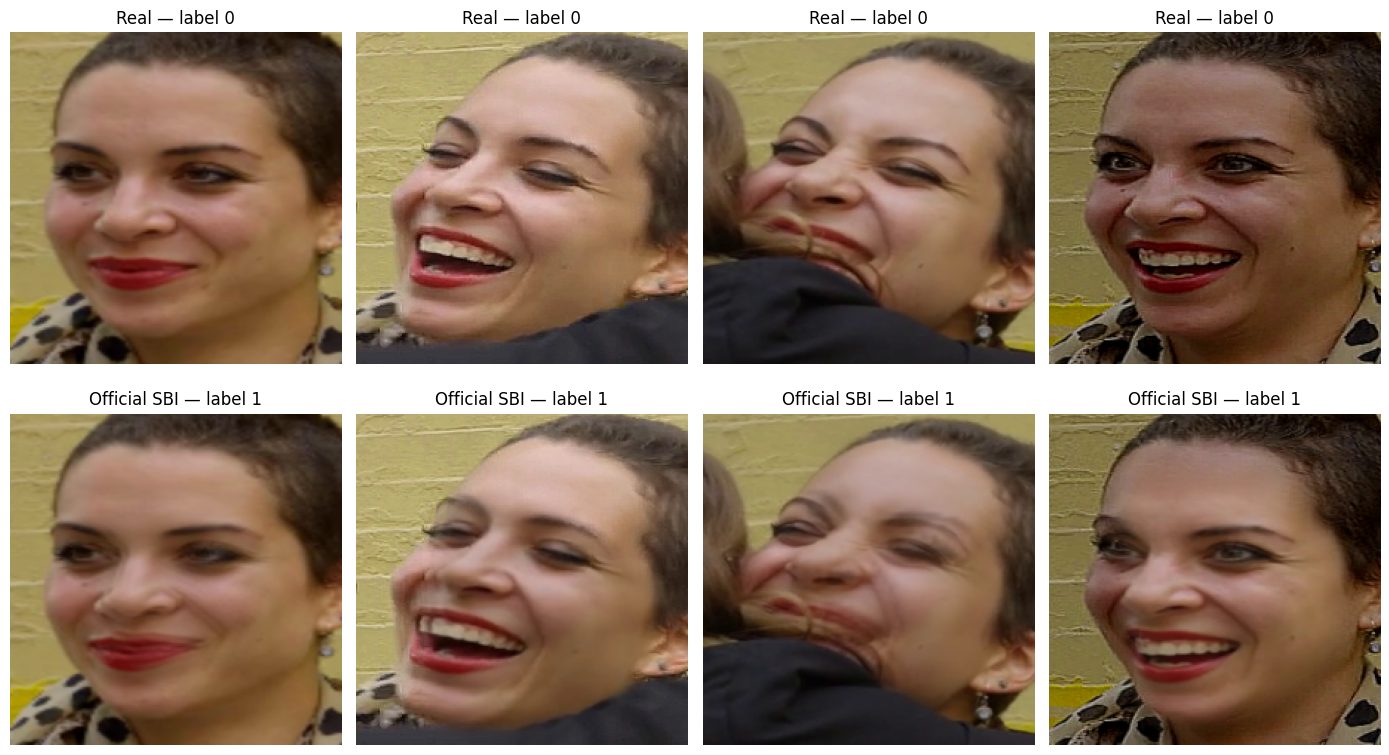

In [5]:
# ============================================================
# E3c input pipeline: identical to E3b Official SBI generation
#
# Uses OUR existing preprocessed dataset:
#   sbi_dataset/<split>/frames/real/
#   sbi_dataset/<split>/retina/real/
#   sbi_dataset/<split>/landmarks/real/
#
# Uses OFFICIAL SBI generation logic:
#   - official crop_face()
#   - official IoU face matching
#   - official landmark reordering and horizontal flip
#   - official source transforms
#   - official affine + elastic mask transformation
#   - official dynamic blending
#   - official paired post-blending augmentation
#
# No files are deleted or generated permanently.
# Synthetic images are created dynamically in memory.
# ============================================================

import os
import sys
import cv2
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import albumentations as alb

from PIL import Image
from torch.utils.data import Dataset, DataLoader


# ------------------------------------------------------------
# Paths and reproducibility
# ------------------------------------------------------------

base_path = "/content/drive/MyDrive/deepfake_project"
sbi_base = os.path.join(base_path, "sbi_dataset")

official_repo = "/content/SelfBlendedImages"
official_src = os.path.join(official_repo, "src")

if not os.path.exists(official_repo):
    raise RuntimeError(
        "Official SBI repository is missing from /content. "
        "Clone or restore SelfBlendedImages after restarting Colab."
    )

if official_src not in sys.path:
    sys.path.insert(0, official_src)

RANDOM_SEED = 42
IMAGE_SIZE = 224

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


# ------------------------------------------------------------
# Import official SBI helper implementations
# ------------------------------------------------------------

from utils import blend as official_blend
from utils.funcs import (
    IoUfrom2bboxes,
    crop_face,
    RandomDownScale
)

print("Official SBI helper functions imported successfully.")


# ------------------------------------------------------------
# Albumentations compatibility helpers
#
# The official repository was written for an older version of
# Albumentations. These wrappers preserve the same parameters
# while supporting current Colab versions.
# ------------------------------------------------------------

def make_image_compression():
    import inspect

    parameters = inspect.signature(
        alb.ImageCompression.__init__
    ).parameters

    if "quality_range" in parameters:
        return alb.ImageCompression(
            quality_range=(40, 100),
            p=0.5
        )

    return alb.ImageCompression(
        quality_lower=40,
        quality_upper=100,
        p=0.5
    )


def make_elastic_transform():
    import inspect

    parameters = inspect.signature(
        alb.ElasticTransform.__init__
    ).parameters

    arguments = {
        "alpha": 50,
        "sigma": 7,
        "p": 1,
    }

    # The official legacy configuration used alpha_affine=0.
    # New releases removed this no-op argument.
    if "alpha_affine" in parameters:
        arguments["alpha_affine"] = 0

    return alb.ElasticTransform(**arguments)


# ------------------------------------------------------------
# Official-style SBI Dataset adapted only to our file paths
# ------------------------------------------------------------

class OfficialSBIDatasetFromOurData(Dataset):

    def __init__(
        self,
        root_path,
        phase="train",
        image_size=224
    ):
        assert phase in ["train", "val"]

        self.root_path = root_path
        self.phase = phase
        self.image_size = (
            image_size,
            image_size
        )

        self.frames_root = os.path.join(
            root_path,
            phase,
            "frames",
            "real"
        )

        self.retina_root = os.path.join(
            root_path,
            phase,
            "retina",
            "real"
        )

        self.landmarks_root = os.path.join(
            root_path,
            phase,
            "landmarks",
            "real"
        )

        self.samples = []

        for video_name in sorted(
            os.listdir(self.frames_root)
        ):
            frame_folder = os.path.join(
                self.frames_root,
                video_name
            )

            if not os.path.isdir(frame_folder):
                continue

            for frame_file in sorted(
                os.listdir(frame_folder)
            ):
                if not frame_file.lower().endswith(
                    ".png"
                ):
                    continue

                stem = os.path.splitext(
                    frame_file
                )[0]

                frame_path = os.path.join(
                    frame_folder,
                    frame_file
                )

                retina_path = os.path.join(
                    self.retina_root,
                    video_name,
                    stem + ".npy"
                )

                landmark_path = os.path.join(
                    self.landmarks_root,
                    video_name,
                    stem + ".npy"
                )

                if (
                    os.path.exists(frame_path)
                    and os.path.exists(retina_path)
                    and os.path.exists(landmark_path)
                ):
                    self.samples.append({
                        "frame": frame_path,
                        "retina": retina_path,
                        "landmarks": landmark_path
                    })

        self.transforms = self.get_transforms()
        self.source_transforms = (
            self.get_source_transforms()
        )

        print(
            f"Official SBI {phase} source frames:",
            len(self.samples)
        )

    def __len__(self):
        return len(self.samples)

    # --------------------------------------------------------
    # Official SBI source transformation
    # --------------------------------------------------------

    def get_source_transforms(self):
        return alb.Compose([
            alb.Compose([
                alb.RGBShift(
                    r_shift_limit=(-20, 20),
                    g_shift_limit=(-20, 20),
                    b_shift_limit=(-20, 20),
                    p=0.3
                ),

                alb.HueSaturationValue(
                    hue_shift_limit=(-0.3, 0.3),
                    sat_shift_limit=(-0.3, 0.3),
                    val_shift_limit=(-0.3, 0.3),
                    p=1
                ),

                alb.RandomBrightnessContrast(
                    brightness_limit=(-0.1, 0.1),
                    contrast_limit=(-0.1, 0.1),
                    p=1
                ),
            ], p=1),

            alb.OneOf([
                RandomDownScale(p=1),

                alb.Sharpen(
                    alpha=(0.2, 0.5),
                    lightness=(0.5, 1.0),
                    p=1
                ),
            ], p=1),
        ], p=1)

    # --------------------------------------------------------
    # Official paired transformation
    #
    # The same random post-blending changes are applied to both
    # the real and generated fake image.
    # --------------------------------------------------------

    def get_transforms(self):
        return alb.Compose([
            alb.RGBShift(
                r_shift_limit=(-20, 20),
                g_shift_limit=(-20, 20),
                b_shift_limit=(-20, 20),
                p=0.3
            ),

            alb.HueSaturationValue(
                hue_shift_limit=(-0.3, 0.3),
                sat_shift_limit=(-0.3, 0.3),
                val_shift_limit=(-0.3, 0.3),
                p=0.3
            ),

            alb.RandomBrightnessContrast(
                brightness_limit=(-0.3, 0.3),
                contrast_limit=(-0.3, 0.3),
                p=0.3
            ),

            make_image_compression(),
        ],
        additional_targets={
            "image1": "image"
        },
        p=1)

    # --------------------------------------------------------
    # Official affine and elastic transformation
    # --------------------------------------------------------

    def randaffine(
        self,
        image,
        mask
    ):
        affine_transform = alb.Affine(
            translate_percent={
                "x": (-0.03, 0.03),
                "y": (-0.015, 0.015)
            },
            scale=(0.95, 1 / 0.95),
            fit_output=False,
            p=1
        )

        elastic_transform = (
            make_elastic_transform()
        )

        transformed = affine_transform(
            image=image,
            mask=mask
        )

        image = transformed["image"]
        mask = transformed["mask"]

        transformed = elastic_transform(
            image=image,
            mask=mask
        )

        mask = transformed["mask"]

        return image, mask

    # --------------------------------------------------------
    # Official landmark ordering
    # --------------------------------------------------------

    def reorder_landmark(
        self,
        landmark
    ):
        landmark = landmark.copy()

        landmark_add = np.zeros(
            (13, 2),
            dtype=landmark.dtype
        )

        official_order = [
            77, 75, 76, 68, 69, 70, 71,
            80, 72, 73, 79, 74, 78
        ]

        for new_index, old_index in enumerate(
            official_order
        ):
            landmark_add[new_index] = (
                landmark[old_index]
            )

        landmark[68:] = landmark_add

        return landmark

    # --------------------------------------------------------
    # Official horizontal flip
    #
    # This mirrors coordinates and reorders anatomical indices.
    # --------------------------------------------------------

    def hflip(
        self,
        image,
        mask=None,
        landmark=None,
        bbox=None
    ):
        height, width = image.shape[:2]

        landmark_new = None
        bbox_new = None

        if landmark is not None:
            landmark = landmark.copy()
            landmark_new = np.zeros_like(
                landmark
            )

            landmark_new[:17] = (
                landmark[:17][::-1]
            )

            landmark_new[17:27] = (
                landmark[17:27][::-1]
            )

            landmark_new[27:31] = (
                landmark[27:31]
            )

            landmark_new[31:36] = (
                landmark[31:36][::-1]
            )

            landmark_new[36:40] = (
                landmark[42:46][::-1]
            )

            landmark_new[40:42] = (
                landmark[46:48][::-1]
            )

            landmark_new[42:46] = (
                landmark[36:40][::-1]
            )

            landmark_new[46:48] = (
                landmark[40:42][::-1]
            )

            landmark_new[48:55] = (
                landmark[48:55][::-1]
            )

            landmark_new[55:60] = (
                landmark[55:60][::-1]
            )

            landmark_new[60:65] = (
                landmark[60:65][::-1]
            )

            landmark_new[65:68] = (
                landmark[65:68][::-1]
            )

            if len(landmark) == 81:
                landmark_new[68:81] = (
                    landmark[68:81][::-1]
                )

            elif len(landmark) != 68:
                raise NotImplementedError(
                    "Expected 68 or 81 landmarks."
                )

            landmark_new[:, 0] = (
                width - landmark_new[:, 0]
            )

        if bbox is not None:
            bbox = bbox.copy()
            bbox_new = np.zeros_like(bbox)

            bbox_new[0, 0] = bbox[1, 0]
            bbox_new[1, 0] = bbox[0, 0]

            bbox_new[:, 0] = (
                width - bbox_new[:, 0]
            )

            bbox_new[:, 1] = (
                bbox[:, 1].copy()
            )

            if len(bbox) > 2:
                bbox_new[2, 0] = (
                    width - bbox[3, 0]
                )
                bbox_new[2, 1] = bbox[3, 1]

                bbox_new[3, 0] = (
                    width - bbox[2, 0]
                )
                bbox_new[3, 1] = bbox[2, 1]

                bbox_new[4, 0] = (
                    width - bbox[4, 0]
                )
                bbox_new[4, 1] = bbox[4, 1]

                bbox_new[5, 0] = (
                    width - bbox[6, 0]
                )
                bbox_new[5, 1] = bbox[6, 1]

                bbox_new[6, 0] = (
                    width - bbox[5, 0]
                )
                bbox_new[6, 1] = bbox[5, 1]

        if mask is not None:
            mask = mask[:, ::-1]

        image = image[:, ::-1].copy()

        return (
            image,
            mask,
            landmark_new,
            bbox_new
        )

    # --------------------------------------------------------
    # Official self-blending logic
    #
    # Because the optional BI mask library is not included in
    # the public repository, this uses the official fallback:
    # cv2.convexHull over the dense landmarks.
    # --------------------------------------------------------

    def self_blending(
        self,
        image,
        landmark
    ):
        mask = np.zeros_like(
            image[:, :, 0],
            dtype=np.float32
        )

        if np.random.rand() < 0.25:
            landmark_for_mask = landmark[:68]
        else:
            landmark_for_mask = landmark

        cv2.fillConvexPoly(
            mask,
            cv2.convexHull(
                landmark_for_mask.astype(
                    np.int32
                )
            ),
            1.0
        )

        source = image.copy()
        target = image.copy()

        # Official code randomly transforms source or target.
        if np.random.rand() < 0.5:
            source = self.source_transforms(
                image=source.astype(np.uint8)
            )["image"]

        else:
            target = self.source_transforms(
                image=target.astype(np.uint8)
            )["image"]

        source, mask = self.randaffine(
            source,
            mask
        )

        blended, mask = (
            official_blend.dynamic_blend(
                source,
                target,
                mask
            )
        )

        blended = blended.astype(np.uint8)
        target = target.astype(np.uint8)

        return target, blended, mask

    # --------------------------------------------------------
    # Load and dynamically generate one official SBI pair
    # --------------------------------------------------------

    def _generate_pair(
        self,
        index
    ):
        sample = self.samples[index]

        image = np.array(
            Image.open(sample["frame"])
            .convert("RGB")
        )

        landmark_array = np.load(
            sample["landmarks"]
        )

        retina_array = np.load(
            sample["retina"]
        )

        landmark = (
            landmark_array[0]
            .astype(np.float32)
        )

        # Dense-landmark bounding rectangle
        bbox_landmark = np.array([
            landmark[:, 0].min(),
            landmark[:, 1].min(),
            landmark[:, 0].max(),
            landmark[:, 1].max()
        ])

        # Select RetinaFace box with highest IoU.
        maximum_iou = -1
        bbox = None

        for candidate in retina_array:
            candidate_iou = (
                IoUfrom2bboxes(
                    bbox_landmark,
                    candidate.flatten()[:4]
                )
            )

            if candidate_iou > maximum_iou:
                bbox = candidate.copy()
                maximum_iou = candidate_iou

        if bbox is None:
            raise RuntimeError(
                "No RetinaFace box matched landmarks."
            )

        landmark = self.reorder_landmark(
            landmark
        )

        # Official random training flip.
        if (
            self.phase == "train"
            and np.random.rand() < 0.5
        ):
            (
                image,
                _,
                landmark,
                bbox
            ) = self.hflip(
                image,
                None,
                landmark,
                bbox
            )

        # Official enlarged working crop.
        (
            image,
            landmark,
            bbox,
            _
        ) = crop_face(
            image,
            landmark,
            bbox,
            margin=True,
            crop_by_bbox=False,
            phase=self.phase
        )

        # Generate official SBI pair.
        image_real, image_fake, _ = (
            self.self_blending(
                image.copy(),
                landmark.copy()
            )
        )

        # Official paired post-blending augmentation.
        if self.phase == "train":
            transformed = self.transforms(
                image=image_fake.astype(
                    np.uint8
                ),
                image1=image_real.astype(
                    np.uint8
                )
            )

            image_fake = transformed["image"]
            image_real = transformed["image1"]

        # Official final crop from generated fake.
        (
            image_fake,
            _,
            _,
            _,
            y0,
            y1,
            x0,
            x1
        ) = crop_face(
            image_fake,
            landmark,
            bbox,
            margin=False,
            crop_by_bbox=True,
            abs_coord=True,
            phase=self.phase
        )

        # Apply identical coordinates to real image.
        image_real = image_real[
            y0:y1,
            x0:x1
        ]

        if (
            image_fake.size == 0
            or image_real.size == 0
        ):
            raise ValueError(
                "Official SBI created empty crop."
            )

        # Official SBI output is resized and divided by 255.
        image_fake = cv2.resize(
            image_fake,
            self.image_size,
            interpolation=cv2.INTER_LINEAR
        ).astype(np.float32) / 255.0

        image_real = cv2.resize(
            image_real,
            self.image_size,
            interpolation=cv2.INTER_LINEAR
        ).astype(np.float32) / 255.0

        image_fake = image_fake.transpose(
            2,
            0,
            1
        )

        image_real = image_real.transpose(
            2,
            0,
            1
        )

        return (
            torch.tensor(
                image_fake,
                dtype=torch.float32
            ),
            torch.tensor(
                image_real,
                dtype=torch.float32
            )
        )

    def __getitem__(
        self,
        index
    ):
        # Keep validation output deterministic.
        if self.phase == "val":
            python_state = random.getstate()
            numpy_state = np.random.get_state()

            random.seed(
                RANDOM_SEED + index
            )
            np.random.seed(
                RANDOM_SEED + index
            )

        try:
            fake_tensor, real_tensor = (
                self._generate_pair(index)
            )

        except Exception as error:
            replacement_index = random.randrange(
                len(self.samples)
            )

            print(
                f"Official SBI sample error at "
                f"index {index}: {error}. "
                f"Using replacement index "
                f"{replacement_index}."
            )

            fake_tensor, real_tensor = (
                self._generate_pair(
                    replacement_index
                )
            )

        if self.phase == "val":
            random.setstate(
                python_state
            )
            np.random.set_state(
                numpy_state
            )

        return fake_tensor, real_tensor


# ------------------------------------------------------------
# Official collate logic
# ------------------------------------------------------------

def official_sbi_collate_fn(batch):
    fake_images, real_images = zip(*batch)

    real_batch = torch.stack(
        real_images
    )

    fake_batch = torch.stack(
        fake_images
    )

    images = torch.cat(
        [
            real_batch,
            fake_batch
        ],
        dim=0
    )

    labels = torch.tensor(
        [0] * len(real_images)
        + [1] * len(fake_images),
        dtype=torch.long
    )

    return {
        "images": images,
        "labels": labels
    }


# ------------------------------------------------------------
# Create E3b loaders
# ------------------------------------------------------------

official_sbi_train_dataset = (
    OfficialSBIDatasetFromOurData(
        sbi_base,
        phase="train",
        image_size=IMAGE_SIZE
    )
)

official_sbi_val_dataset = (
    OfficialSBIDatasetFromOurData(
        sbi_base,
        phase="val",
        image_size=IMAGE_SIZE
    )
)

# Eight source frames produce:
# 8 real + 8 official SBI fake = 16 model inputs.
OFFICIAL_SBI_SOURCE_BATCH_SIZE = 8

official_sbi_train_loader = DataLoader(
    official_sbi_train_dataset,
    batch_size=OFFICIAL_SBI_SOURCE_BATCH_SIZE,
    shuffle=True,
    collate_fn=official_sbi_collate_fn,
    num_workers=0,
    pin_memory=True,
    drop_last=True
)

official_sbi_val_loader = DataLoader(
    official_sbi_val_dataset,
    batch_size=OFFICIAL_SBI_SOURCE_BATCH_SIZE,
    shuffle=False,
    collate_fn=official_sbi_collate_fn,
    num_workers=0,
    pin_memory=True
)


# ------------------------------------------------------------
# Sanity-check one official SBI batch
# ------------------------------------------------------------

official_batch = next(
    iter(official_sbi_train_loader)
)

print()
print(
    "Official SBI batch shape:",
    official_batch["images"].shape
)

print(
    "Official SBI label shape:",
    official_batch["labels"].shape
)

print(
    "Labels:",
    official_batch["labels"].tolist()
)


# ------------------------------------------------------------
# Display four deterministic validation real/official-SBI pairs
# ------------------------------------------------------------

official_preview_batch = next(
    iter(official_sbi_val_loader)
)

number_of_pairs = 4

plt.figure(figsize=(14, 8))

for pair_index in range(
    number_of_pairs
):
    real_image = (
        official_preview_batch["images"][
            pair_index
        ]
        .cpu()
        .numpy()
        .transpose(1, 2, 0)
    )

    fake_image = (
        official_preview_batch["images"][
            OFFICIAL_SBI_SOURCE_BATCH_SIZE
            + pair_index
        ]
        .cpu()
        .numpy()
        .transpose(1, 2, 0)
    )

    plt.subplot(
        2,
        number_of_pairs,
        pair_index + 1
    )

    plt.imshow(
        np.clip(real_image, 0, 1)
    )

    plt.title(
        "Real — label 0"
    )

    plt.axis("off")

    plt.subplot(
        2,
        number_of_pairs,
        number_of_pairs
        + pair_index
        + 1
    )

    plt.imshow(
        np.clip(fake_image, 0, 1)
    )

    plt.title(
        "Official SBI — label 1"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

## 6. Train E3c with SAM and save the best checkpoint

This preserves the original two-pass SAM update, SGD base optimiser, BatchNorm safeguard, scheduler, reproducibility settings and best-synthetic-validation-ROC-AUC checkpoint rule. With `RUN_TRAINING = False`, it performs no training and overwrites nothing.


Using device: cuda
GPU: Tesla T4
Real training source frames: 1342
Real validation source frames: 290
Source batch size: 8
Effective model batch size: 16
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 133MB/s] 


Trainable parameters: 4,010,110

Experiment: E3c
Optimiser: SAM with SGD
Initial learning rate: 0.001
Momentum: 0.9
Weight decay: 0.0001
SAM rho: 0.05
Maximum epochs: 10
Epoch 1 Batch 0/167 First Loss: 0.6953 | Second Loss: 0.7237
Epoch 1 Batch 20/167 First Loss: 0.6692 | Second Loss: 0.7302
Epoch 1 Batch 40/167 First Loss: 0.6642 | Second Loss: 0.7267
Epoch 1 Batch 60/167 First Loss: 0.6259 | Second Loss: 0.6733
Epoch 1 Batch 80/167 First Loss: 0.5674 | Second Loss: 0.6652
Epoch 1 Batch 100/167 First Loss: 0.6663 | Second Loss: 0.7200
Epoch 1 Batch 120/167 First Loss: 0.5689 | Second Loss: 0.6785
Epoch 1 Batch 140/167 First Loss: 0.5844 | Second Loss: 0.6240
Epoch 1 Batch 160/167 First Loss: 0.5143 | Second Loss: 0.5963

Epoch [1/10]
Train Loss: 0.6347 | Train Acc: 64.90% | Train Precision: 65.03% | Train Recall: 64.90% | Train F1: 64.82% | Train AUC: 0.7110
Val Loss: 0.5713 | Val Acc: 69.66% | Val Precision: 71.85% | Val Recall: 69.66% | Val F1: 68.87% | Val AUC: 0.8176
Learning rate

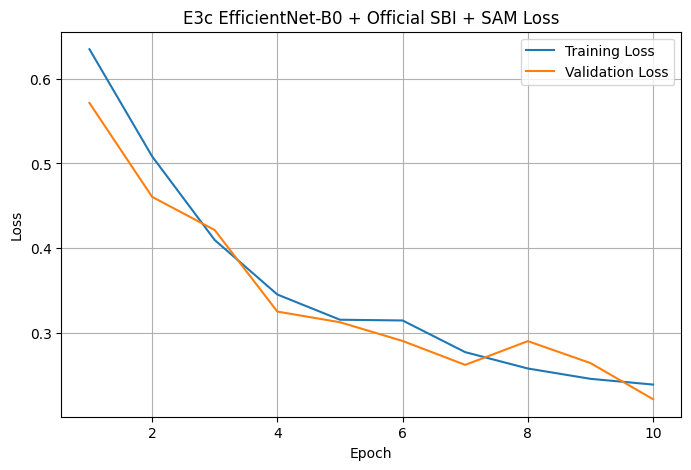

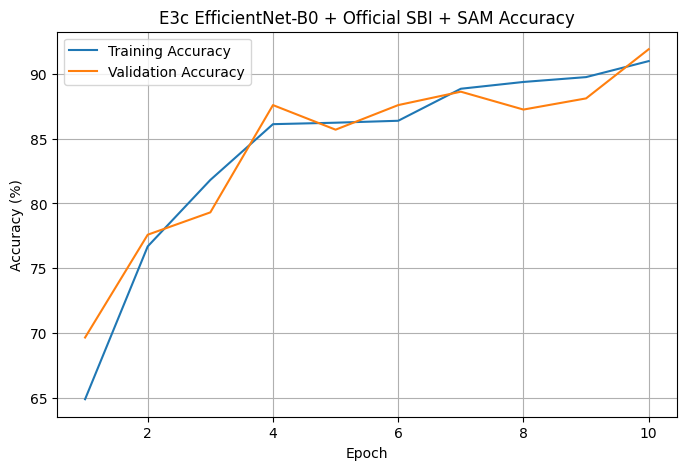

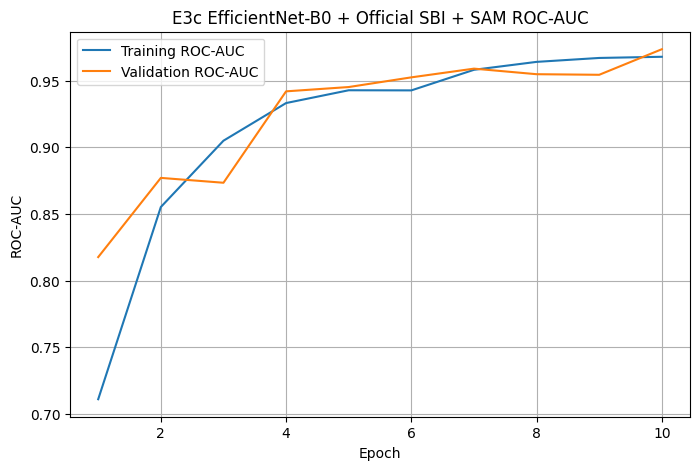


Loss plot saved to: /content/drive/MyDrive/deepfake_project/plots/efficientnet_b0_official_sbi_sam_loss.png
Accuracy plot saved to: /content/drive/MyDrive/deepfake_project/plots/efficientnet_b0_official_sbi_sam_accuracy.png
ROC-AUC plot saved to: /content/drive/MyDrive/deepfake_project/plots/efficientnet_b0_official_sbi_sam_auc.png


In [6]:
# ============================================================
# E3c: EfficientNet-B0 with Official SBI + SAM
#
# Controlled change from E3b:
#   Adam optimiser -> SAM with SGD
#
# Training source:
#   Real FF++ training frames only
#
# Dynamic training pairs:
#   Original real image -> label 0
#   Official SBI fake   -> label 1
#
# Validation:
#   Real validation frames + dynamically generated SBI fakes
#
# Backbone:
#   ImageNet-pretrained EfficientNet-B0
#   Full fine-tuning
#
# Optimisation:
#   Sharpness-Aware Minimisation (SAM)
#   Base optimiser: SGD
#
# Model selection:
#   Best validation ROC-AUC
#
# Safety:
#   Uses separate E3c model, result and plot filenames.
#   Does not overwrite E3b.
# ============================================================

if RUN_TRAINING:

    # --------------------------------------------------------
    # Imports
    # --------------------------------------------------------

    import os
    import json
    import time
    import random
    import numpy as np
    import torch
    import torch.nn as nn
    import torch.optim as optim
    import matplotlib.pyplot as plt

    from torchvision.models import (
        efficientnet_b0,
        EfficientNet_B0_Weights
    )

    from sklearn.metrics import (
        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        roc_auc_score
    )

    # --------------------------------------------------------
    # Paths
    # --------------------------------------------------------

    base_path = (
        "/content/drive/MyDrive/deepfake_project"
    )

    model_dir = os.path.join(
        base_path,
        "saved_models"
    )

    results_dir = os.path.join(
        base_path,
        "results"
    )

    plots_dir = os.path.join(
        base_path,
        "plots"
    )

    os.makedirs(
        model_dir,
        exist_ok=True
    )

    os.makedirs(
        results_dir,
        exist_ok=True
    )

    os.makedirs(
        plots_dir,
        exist_ok=True
    )

    model_path = os.path.join(
        model_dir,
        CHECKPOINT_NAME
    )

    results_path = os.path.join(
        results_dir,
        RESULTS_NAME
    )

    # --------------------------------------------------------
    # Plot paths
    # --------------------------------------------------------

    loss_plot_path = os.path.join(
        plots_dir,
        LOSS_PLOT_NAME
    )

    accuracy_plot_path = os.path.join(
        plots_dir,
        ACCURACY_PLOT_NAME
    )

    auc_plot_path = os.path.join(
        plots_dir,
        AUC_PLOT_NAME
    )

    # --------------------------------------------------------
    # Device
    # --------------------------------------------------------

    device = torch.device(
        "cuda"
        if torch.cuda.is_available()
        else "cpu"
    )

    print("Using device:", device)

    if torch.cuda.is_available():

        print(
            "GPU:",
            torch.cuda.get_device_name(0)
        )

        torch.cuda.empty_cache()

    # --------------------------------------------------------
    # Confirm required loaders exist
    # --------------------------------------------------------

    required_objects = [
        "official_sbi_train_loader",
        "official_sbi_val_loader",
        "OFFICIAL_SBI_SOURCE_BATCH_SIZE"
    ]

    missing_objects = [
        name
        for name in required_objects
        if name not in globals()
    ]

    if missing_objects:

        raise RuntimeError(
            "Run the official SBI loader cell first. "
            f"Missing objects: {missing_objects}"
        )

    print(
        "Real training source frames:",
        len(official_sbi_train_loader.dataset)
    )

    print(
        "Real validation source frames:",
        len(official_sbi_val_loader.dataset)
    )

    print(
        "Source batch size:",
        OFFICIAL_SBI_SOURCE_BATCH_SIZE
    )

    print(
        "Effective model batch size:",
        OFFICIAL_SBI_SOURCE_BATCH_SIZE * 2
    )

    # --------------------------------------------------------
    # Reproducibility
    # --------------------------------------------------------

    RANDOM_SEED = 42

    random.seed(
        RANDOM_SEED
    )

    np.random.seed(
        RANDOM_SEED
    )

    torch.manual_seed(
        RANDOM_SEED
    )

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(
            RANDOM_SEED
        )

    # Reproducibility settings.
    # benchmark=False is more reproducible but can be slower.
    if torch.backends.cudnn.is_available():

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    # --------------------------------------------------------
    # Training configuration
    # --------------------------------------------------------

    NUM_EPOCHS = 10

    # SAM with SGD configuration.
    LEARNING_RATE = 1e-3
    MOMENTUM = 0.9
    WEIGHT_DECAY = 1e-4
    SAM_RHO = 0.05

    # --------------------------------------------------------
    # SAM optimiser
    # --------------------------------------------------------

    class SAM(torch.optim.Optimizer):
        """
        Sharpness-Aware Minimisation.

        SAM performs two forward/backward passes:

        First pass:
            Calculate gradients at the current parameters.

        Perturbation:
            Move parameters towards a nearby high-loss point.

        Second pass:
            Calculate gradients at the perturbed parameters.

        Final update:
            Restore the original parameters and apply the
            base optimiser update using the second gradients.
        """

        def __init__(
            self,
            params,
            base_optimizer,
            rho=0.05,
            adaptive=False,
            **kwargs
        ):

            if rho < 0:

                raise ValueError(
                    f"Invalid SAM rho value: {rho}"
                )

            defaults = {
                "rho": rho,
                "adaptive": adaptive,
                **kwargs
            }

            super().__init__(
                params,
                defaults
            )

            self.base_optimizer = base_optimizer(
                self.param_groups,
                **kwargs
            )

            # Use the base optimiser parameter groups so that
            # learning-rate schedulers update the same groups.
            self.param_groups = (
                self.base_optimizer.param_groups
            )

            self.defaults.update(
                self.base_optimizer.defaults
            )

        @torch.no_grad()
        def first_step(
            self,
            zero_grad=False
        ):
            """
            Move the parameters to the local high-loss point.
            """

            gradient_norm = (
                self._gradient_norm()
            )

            for group in self.param_groups:

                scale = (
                    group["rho"]
                    / (
                        gradient_norm
                        + 1e-12
                    )
                )

                for parameter in group["params"]:

                    if parameter.grad is None:
                        continue

                    if group["adaptive"]:

                        perturbation = (
                            torch.pow(
                                parameter,
                                2
                            )
                            * parameter.grad
                            * scale.to(
                                parameter
                            )
                        )

                    else:

                        perturbation = (
                            parameter.grad
                            * scale.to(
                                parameter
                            )
                        )

                    parameter.add_(
                        perturbation
                    )

                    self.state[parameter][
                        "sam_perturbation"
                    ] = perturbation

            if zero_grad:

                self.zero_grad(
                    set_to_none=True
                )

        @torch.no_grad()
        def second_step(
            self,
            zero_grad=False
        ):
            """
            Restore the original parameters and apply the SGD
            update using gradients from the perturbed point.
            """

            for group in self.param_groups:

                for parameter in group["params"]:

                    perturbation = (
                        self.state[
                            parameter
                        ].pop(
                            "sam_perturbation",
                            None
                        )
                    )

                    if perturbation is not None:

                        parameter.sub_(
                            perturbation
                        )

            self.base_optimizer.step()

            if zero_grad:

                self.zero_grad(
                    set_to_none=True
                )

        @torch.no_grad()
        def step(
            self,
            closure=None
        ):
            """
            Optional closure-based SAM step.

            The explicit first_step and second_step calls are
            used in this training loop.
            """

            if closure is None:

                raise RuntimeError(
                    "SAM requires a closure or explicit "
                    "first_step/second_step calls."
                )

            closure = torch.enable_grad()(
                closure
            )

            self.first_step(
                zero_grad=True
            )

            closure()

            self.second_step(
                zero_grad=True
            )

        def _gradient_norm(self):
            """
            Calculate the combined L2 norm of the gradients.
            """

            shared_device = (
                self.param_groups[0]
                ["params"][0]
                .device
            )

            norms = []

            for group in self.param_groups:

                for parameter in group["params"]:

                    if parameter.grad is None:
                        continue

                    if group["adaptive"]:

                        gradient = (
                            torch.abs(
                                parameter
                            )
                            * parameter.grad
                        )

                    else:

                        gradient = (
                            parameter.grad
                        )

                    norms.append(
                        gradient.norm(
                            p=2
                        ).to(
                            shared_device
                        )
                    )

            if not norms:

                return torch.tensor(
                    0.0,
                    device=shared_device
                )

            return torch.norm(
                torch.stack(
                    norms
                ),
                p=2
            )

        def state_dict(self):
            """
            Save both the SAM state and the SGD base-optimiser
            state.
            """

            return {
                "sam_state":
                    super().state_dict(),

                "base_optimizer_state":
                    self.base_optimizer.state_dict()
            }

        def load_state_dict(
            self,
            state_dict
        ):
            """
            Restore both SAM and base-optimiser states.
            """

            if (
                "sam_state" in state_dict
                and
                "base_optimizer_state"
                in state_dict
            ):

                super().load_state_dict(
                    state_dict["sam_state"]
                )

                self.base_optimizer.load_state_dict(
                    state_dict[
                        "base_optimizer_state"
                    ]
                )

                self.param_groups = (
                    self.base_optimizer.param_groups
                )

            else:

                # Compatibility fallback.
                super().load_state_dict(
                    state_dict
                )

    # --------------------------------------------------------
    # BatchNorm handling for SAM
    # --------------------------------------------------------

    def disable_running_stats(model):
        """
        Disable BatchNorm running-statistic updates during the
        second SAM forward pass.

        This prevents the same batch from updating BatchNorm
        running statistics twice.
        """

        def _disable(module):

            if isinstance(
                module,
                torch.nn.modules.batchnorm._BatchNorm
            ):

                if not hasattr(
                    module,
                    "backup_momentum"
                ):

                    module.backup_momentum = (
                        module.momentum
                    )

                module.momentum = 0

        model.apply(
            _disable
        )

    def enable_running_stats(model):
        """
        Restore normal BatchNorm running-statistic updates.
        """

        def _enable(module):

            if (
                isinstance(
                    module,
                    torch.nn.modules.batchnorm._BatchNorm
                )
                and
                hasattr(
                    module,
                    "backup_momentum"
                )
            ):

                module.momentum = (
                    module.backup_momentum
                )

        model.apply(
            _enable
        )

    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    weights = (
        EfficientNet_B0_Weights.DEFAULT
    )

    model = efficientnet_b0(
        weights=weights
    )

    model.classifier[1] = nn.Linear(
        model.classifier[1].in_features,
        2
    )

    # Full fine-tuning.
    for parameter in model.parameters():

        parameter.requires_grad = True

    model = model.to(
        device
    )

    trainable_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    print(
        "Trainable parameters:",
        f"{trainable_parameters:,}"
    )

    # --------------------------------------------------------
    # Loss, optimiser and scheduler
    # --------------------------------------------------------

    criterion = nn.CrossEntropyLoss()

    optimizer = SAM(
        model.parameters(),
        base_optimizer=optim.SGD,
        rho=SAM_RHO,
        adaptive=False,
        lr=LEARNING_RATE,
        momentum=MOMENTUM,
        weight_decay=WEIGHT_DECAY
    )

    scheduler = (
        optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="max",
            factor=0.5,
            patience=2
        )
    )

    print()
    print("Experiment: E3c")
    print("Optimiser: SAM with SGD")
    print("Initial learning rate:", LEARNING_RATE)
    print("Momentum:", MOMENTUM)
    print("Weight decay:", WEIGHT_DECAY)
    print("SAM rho:", SAM_RHO)
    print("Maximum epochs:", NUM_EPOCHS)

    # --------------------------------------------------------
    # Metric helper
    # --------------------------------------------------------

    def calculate_binary_metrics(
        labels,
        predictions,
        fake_probabilities
    ):

        accuracy = accuracy_score(
            labels,
            predictions
        ) * 100

        precision = precision_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ) * 100

        recall = recall_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ) * 100

        f1 = f1_score(
            labels,
            predictions,
            average="macro",
            zero_division=0
        ) * 100

        try:

            auc = roc_auc_score(
                labels,
                fake_probabilities
            )

        except ValueError:

            auc = None

        return {
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "roc_auc": auc
        }

    # --------------------------------------------------------
    # Training history
    # --------------------------------------------------------

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "train_precision": [],
        "train_recall": [],
        "train_f1": [],
        "train_roc_auc": [],

        "val_loss": [],
        "val_accuracy": [],
        "val_precision": [],
        "val_recall": [],
        "val_f1": [],
        "val_roc_auc": [],

        "learning_rate": []
    }

    best_val_auc = -1.0
    best_val_accuracy = 0.0
    best_val_f1 = 0.0
    best_epoch = 0

    training_start_time = time.time()

    # --------------------------------------------------------
    # Epoch loop
    # --------------------------------------------------------

    for epoch in range(
        NUM_EPOCHS
    ):

        epoch_start_time = time.time()

        # ====================================================
        # Training phase
        # ====================================================

        model.train()

        running_train_loss = 0.0

        train_labels = []
        train_predictions = []
        train_probabilities = []

        for batch_index, batch in enumerate(
            official_sbi_train_loader
        ):

            images = batch["images"].to(
                device,
                non_blocking=True
            )

            labels = batch["labels"].to(
                device,
                non_blocking=True
            )

            # ------------------------------------------------
            # SAM first forward/backward pass
            # ------------------------------------------------

            enable_running_stats(
                model
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            outputs = model(
                images
            )

            first_loss = criterion(
                outputs,
                labels
            )

            first_loss.backward()

            optimizer.first_step(
                zero_grad=True
            )

            # ------------------------------------------------
            # SAM second forward/backward pass
            # ------------------------------------------------

            disable_running_stats(
                model
            )

            second_outputs = model(
                images
            )

            second_loss = criterion(
                second_outputs,
                labels
            )

            second_loss.backward()

            optimizer.second_step(
                zero_grad=True
            )

            # Restore normal BatchNorm behaviour.
            enable_running_stats(
                model
            )

            # Use the unperturbed first-pass loss and outputs
            # for metric recording.
            loss = first_loss

            running_train_loss += (
                loss.item()
            )

            fake_probabilities = (
                torch.softmax(
                    outputs.detach(),
                    dim=1
                )[:, 1]
            )

            predictions = torch.argmax(
                outputs.detach(),
                dim=1
            )

            train_labels.extend(
                labels
                .detach()
                .cpu()
                .numpy()
                .tolist()
            )

            train_predictions.extend(
                predictions
                .cpu()
                .numpy()
                .tolist()
            )

            train_probabilities.extend(
                fake_probabilities
                .cpu()
                .numpy()
                .tolist()
            )

            if batch_index % 20 == 0:

                print(
                    f"Epoch {epoch + 1} "
                    f"Batch {batch_index}/"
                    f"{len(official_sbi_train_loader)} "
                    f"First Loss: "
                    f"{first_loss.item():.4f} | "
                    f"Second Loss: "
                    f"{second_loss.item():.4f}"
                )

        average_train_loss = (
            running_train_loss
            / len(official_sbi_train_loader)
        )

        train_metrics = (
            calculate_binary_metrics(
                train_labels,
                train_predictions,
                train_probabilities
            )
        )

        # ====================================================
        # Validation phase
        # ====================================================

        model.eval()

        running_val_loss = 0.0

        val_labels = []
        val_predictions = []
        val_probabilities = []

        with torch.no_grad():

            for batch in official_sbi_val_loader:

                images = batch["images"].to(
                    device,
                    non_blocking=True
                )

                labels = batch["labels"].to(
                    device,
                    non_blocking=True
                )

                outputs = model(
                    images
                )

                loss = criterion(
                    outputs,
                    labels
                )

                running_val_loss += (
                    loss.item()
                )

                fake_probabilities = (
                    torch.softmax(
                        outputs,
                        dim=1
                    )[:, 1]
                )

                predictions = torch.argmax(
                    outputs,
                    dim=1
                )

                val_labels.extend(
                    labels
                    .detach()
                    .cpu()
                    .numpy()
                    .tolist()
                )

                val_predictions.extend(
                    predictions
                    .detach()
                    .cpu()
                    .numpy()
                    .tolist()
                )

                val_probabilities.extend(
                    fake_probabilities
                    .detach()
                    .cpu()
                    .numpy()
                    .tolist()
                )

        average_val_loss = (
            running_val_loss
            / len(official_sbi_val_loader)
        )

        val_metrics = (
            calculate_binary_metrics(
                val_labels,
                val_predictions,
                val_probabilities
            )
        )

        # Record the learning rate used during this epoch,
        # before the scheduler potentially changes it.
        current_learning_rate = (
            optimizer.param_groups[0]["lr"]
        )

        scheduler_value = (
            val_metrics["roc_auc"]
            if val_metrics["roc_auc"] is not None
            else val_metrics["accuracy"] / 100
        )

        scheduler.step(
            scheduler_value
        )

        next_learning_rate = (
            optimizer.param_groups[0]["lr"]
        )

        # ----------------------------------------------------
        # Save history
        # ----------------------------------------------------

        history["train_loss"].append(
            average_train_loss
        )

        history["train_accuracy"].append(
            train_metrics["accuracy"]
        )

        history["train_precision"].append(
            train_metrics["precision"]
        )

        history["train_recall"].append(
            train_metrics["recall"]
        )

        history["train_f1"].append(
            train_metrics["f1"]
        )

        history["train_roc_auc"].append(
            train_metrics["roc_auc"]
        )

        history["val_loss"].append(
            average_val_loss
        )

        history["val_accuracy"].append(
            val_metrics["accuracy"]
        )

        history["val_precision"].append(
            val_metrics["precision"]
        )

        history["val_recall"].append(
            val_metrics["recall"]
        )

        history["val_f1"].append(
            val_metrics["f1"]
        )

        history["val_roc_auc"].append(
            val_metrics["roc_auc"]
        )

        history["learning_rate"].append(
            current_learning_rate
        )

        epoch_time = (
            time.time()
            - epoch_start_time
        )

        # ----------------------------------------------------
        # Epoch logging
        # ----------------------------------------------------

        print()
        print(
            f"Epoch [{epoch + 1}/{NUM_EPOCHS}]"
        )

        print(
            f"Train Loss: "
            f"{average_train_loss:.4f} | "
            f"Train Acc: "
            f"{train_metrics['accuracy']:.2f}% | "
            f"Train Precision: "
            f"{train_metrics['precision']:.2f}% | "
            f"Train Recall: "
            f"{train_metrics['recall']:.2f}% | "
            f"Train F1: "
            f"{train_metrics['f1']:.2f}% | "
            f"Train AUC: "
            f"{train_metrics['roc_auc']:.4f}"
        )

        print(
            f"Val Loss: "
            f"{average_val_loss:.4f} | "
            f"Val Acc: "
            f"{val_metrics['accuracy']:.2f}% | "
            f"Val Precision: "
            f"{val_metrics['precision']:.2f}% | "
            f"Val Recall: "
            f"{val_metrics['recall']:.2f}% | "
            f"Val F1: "
            f"{val_metrics['f1']:.2f}% | "
            f"Val AUC: "
            f"{val_metrics['roc_auc']:.4f}"
        )

        print(
            "Learning rate used:",
            f"{current_learning_rate:.8f}"
        )

        if next_learning_rate != current_learning_rate:

            print(
                "Scheduler changed learning rate to:",
                f"{next_learning_rate:.8f}"
            )

        print(
            "Epoch time:",
            f"{epoch_time / 60:.2f} minutes"
        )

        # ----------------------------------------------------
        # Save checkpoint with best validation ROC-AUC
        # ----------------------------------------------------

        current_val_auc = (
            val_metrics["roc_auc"]
            if val_metrics["roc_auc"] is not None
            else -1.0
        )

        if current_val_auc > best_val_auc:

            best_val_auc = (
                current_val_auc
            )

            best_val_accuracy = (
                val_metrics["accuracy"]
            )

            best_val_f1 = (
                val_metrics["f1"]
            )

            best_epoch = (
                epoch + 1
            )

            checkpoint = {
                "experiment":
                    "E3c",

                "model_name":
                    "EfficientNet-B0 + Official SBI + SAM",

                "backbone":
                    "EfficientNet-B0",

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "scheduler_state_dict":
                    scheduler.state_dict(),

                "epoch":
                    best_epoch,

                "best_val_auc":
                    best_val_auc,

                "best_val_accuracy":
                    best_val_accuracy,

                "best_val_f1":
                    best_val_f1,

                "optimizer":
                    "SAM with SGD",

                "base_optimizer":
                    "SGD",

                "learning_rate":
                    LEARNING_RATE,

                "momentum":
                    MOMENTUM,

                "weight_decay":
                    WEIGHT_DECAY,

                "sam_rho":
                    SAM_RHO,

                "sam_adaptive":
                    False,

                "source_batch_size":
                    OFFICIAL_SBI_SOURCE_BATCH_SIZE,

                "effective_batch_size":
                    OFFICIAL_SBI_SOURCE_BATCH_SIZE * 2,

                "input_size":
                    224,

                "classes": [
                    "real",
                    "fake"
                ],

                "preprocessing":
                    "resize 224x224; float32 / 255; no ImageNet normalisation",

                "validation_type":
                    "deterministic real/SBI synthetic pairs",

                "split_unit":
                    "source_video",

                "seed":
                    RANDOM_SEED
            }

            torch.save(
                checkpoint,
                model_path
            )

            print(
                "*** Best E3c SBI + SAM model "
                f"updated at Epoch {best_epoch} | "
                f"Val AUC: {best_val_auc:.4f} | "
                f"Val Accuracy: "
                f"{best_val_accuracy:.2f}% | "
                f"Val F1: "
                f"{best_val_f1:.2f}% ***"
            )

        print(
            "-" * 75
        )

    # --------------------------------------------------------
    # Training completed
    # --------------------------------------------------------

    total_training_time = (
        time.time()
        - training_start_time
    )

    training_results = {
        "experiment":
            "E3c",

        "model":
            "EfficientNet-B0 + Official SBI + SAM",

        "backbone":
            "EfficientNet-B0",

        "input_size":
            224,

        "pretrained_on":
            "ImageNet",

        "fine_tuning":
            True,

        "backbone_frozen":
            False,

        "training_source":
            "Real FF++ training videos only",

        "genuine_fake_training_images_used":
            False,

        "synthetic_fake_generation":
            "Official SBI generation logic",

        "epochs":
            NUM_EPOCHS,

        "source_batch_size":
            OFFICIAL_SBI_SOURCE_BATCH_SIZE,

        "effective_batch_size":
            OFFICIAL_SBI_SOURCE_BATCH_SIZE * 2,

        "learning_rate":
            LEARNING_RATE,

        "momentum":
            MOMENTUM,

        "weight_decay":
            WEIGHT_DECAY,

        "optimizer":
            "SAM with SGD",

        "base_optimizer":
            "SGD",

        "sam_rho":
            SAM_RHO,

        "sam_adaptive":
            False,

        "loss":
            "CrossEntropyLoss",

        "scheduler":
            "ReduceLROnPlateau",

        "scheduler_mode":
            "max",

        "scheduler_factor":
            0.5,

        "scheduler_patience":
            2,

        "checkpoint_selection":
            "Best synthetic validation ROC-AUC",

        "validation_type":
            "deterministic real/SBI synthetic pairs",

        "preprocessing":
            "resize 224x224; float32 / 255; no ImageNet normalisation",

        "split_unit":
            "source_video",

        "seed":
            RANDOM_SEED,

        "label_mapping": {
            "real": 0,
            "fake": 1
        },

        "best_epoch":
            best_epoch,

        "best_val_auc":
            best_val_auc,

        "best_val_accuracy":
            best_val_accuracy,

        "best_val_f1":
            best_val_f1,

        "final_train_loss":
            history["train_loss"][-1],

        "final_val_loss":
            history["val_loss"][-1],

        "total_training_time_minutes":
            round(
                total_training_time / 60,
                2
            ),

        "model_path":
            model_path,

        "results_path":
            results_path,

        "history":
            history
    }

    with open(
        results_path,
        "w"
    ) as file:

        json.dump(
            training_results,
            file,
            indent=4
        )

    print()
    print(
        "E3c official SBI + SAM training completed."
    )

    print(
        "Best Validation ROC-AUC:",
        f"{best_val_auc:.4f}"
    )

    print(
        "Validation Accuracy at Best AUC:",
        f"{best_val_accuracy:.2f}%"
    )

    print(
        "Validation F1 at Best AUC:",
        f"{best_val_f1:.2f}%"
    )

    print(
        "Best Epoch:",
        best_epoch
    )

    print(
        "Total training time:",
        f"{total_training_time / 60:.2f} minutes"
    )

    print(
        "Best model saved to:",
        model_path
    )

    print(
        "Training results saved to:",
        results_path
    )

    # --------------------------------------------------------
    # Plot loss
    # --------------------------------------------------------

    epochs = range(
        1,
        NUM_EPOCHS + 1
    )

    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        epochs,
        history["train_loss"],
        label="Training Loss"
    )

    plt.plot(
        epochs,
        history["val_loss"],
        label="Validation Loss"
    )

    plt.title(
        "E3c EfficientNet-B0 + Official SBI + SAM Loss"
    )

    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "Loss"
    )

    plt.legend()
    plt.grid(True)

    plt.savefig(
        loss_plot_path,
        bbox_inches="tight"
    )

    plt.show()

    # --------------------------------------------------------
    # Plot accuracy
    # --------------------------------------------------------

    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        epochs,
        history["train_accuracy"],
        label="Training Accuracy"
    )

    plt.plot(
        epochs,
        history["val_accuracy"],
        label="Validation Accuracy"
    )

    plt.title(
        "E3c EfficientNet-B0 + Official SBI + SAM Accuracy"
    )

    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "Accuracy (%)"
    )

    plt.legend()
    plt.grid(True)

    plt.savefig(
        accuracy_plot_path,
        bbox_inches="tight"
    )

    plt.show()

    # --------------------------------------------------------
    # Plot ROC-AUC
    # --------------------------------------------------------

    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        epochs,
        history["train_roc_auc"],
        label="Training ROC-AUC"
    )

    plt.plot(
        epochs,
        history["val_roc_auc"],
        label="Validation ROC-AUC"
    )

    plt.title(
        "E3c EfficientNet-B0 + Official SBI + SAM ROC-AUC"
    )

    plt.xlabel(
        "Epoch"
    )

    plt.ylabel(
        "ROC-AUC"
    )

    plt.legend()
    plt.grid(True)

    plt.savefig(
        auc_plot_path,
        bbox_inches="tight"
    )

    plt.show()

    print()
    print(
        "Loss plot saved to:",
        loss_plot_path
    )

    print(
        "Accuracy plot saved to:",
        accuracy_plot_path
    )

    print(
        "ROC-AUC plot saved to:",
        auc_plot_path
    )


else:

    print(
        "E3c official SBI + SAM training skipped. "
        "Set RUN_TRAINING = True."
    )

## 7. Next notebook

Use `04h_E3c_FFPP_Evaluation.ipynb` to load `efficientnet_b0_official_sbi_sam_best.pth` and evaluate it on the same genuine 591 FF++ face crops and 60 source videos used for E2.2, E3a and E3b.

Evaluation preprocessing must match E3c: resize to 224×224, convert to float32, divide by 255, and apply **no ImageNet normalisation**. Use output 0 = real, output 1 = fake and threshold 0.5. Do not generate SBI samples or tune the threshold on the test set.
